In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

from data.parsers.highd_parser import *
from data.feature_engineering.platoon_extractor import *
from data.feature_engineering.profile_generator import *

In [2]:
tracks_df, meta_df = load_all_recordings()

print(tracks_df.shape)
print(meta_df.shape)

Loading recording 01
Loading recording 02
Loading recording 03
Loading recording 04
Loading recording 05
Loading recording 06
Loading recording 07
Loading recording 08
Loading recording 09
Loading recording 10
Loading recording 11
Loading recording 12
Loading recording 13
Loading recording 14
Loading recording 15
Loading recording 16
Loading recording 17
Loading recording 18
Loading recording 19
Loading recording 20
Loading recording 21
Loading recording 22
Loading recording 23
Loading recording 24
Loading recording 25
Loading recording 26
Loading recording 27
Loading recording 28
Loading recording 29
Loading recording 30
Loading recording 31
Loading recording 32
Loading recording 33
Loading recording 34
Loading recording 35
Loading recording 36
Loading recording 37
Loading recording 38
Loading recording 39
Loading recording 40
Loading recording 41
Loading recording 42
Loading recording 43
Loading recording 44
Loading recording 45
Loading recording 46
Loading recording 47
Loading recor

In [3]:
truck_tracks, truck_meta = filter_trucks(tracks_df, meta_df)
truck_tracks = keep_longitudinal_columns(truck_tracks)
truck_tracks.head()

,recordingId,frame,id,laneId,precedingId,followingId,x,xVelocity,xAcceleration,dhw,thw,ttc
0,1,1,1,5,0,3,362.26,40.85,0.30,0.0,0.0,0.0
1,1,2,1,5,0,14,363.73,40.87,0.30,0.0,0.0,0.0
2,1,3,1,5,0,14,365.27,40.88,0.31,0.0,0.0,0.0
3,1,4,1,5,0,14,366.83,40.89,0.32,0.0,0.0,0.0
4,1,5,1,5,0,14,368.42,40.90,0.32,0.0,0.0,0.0


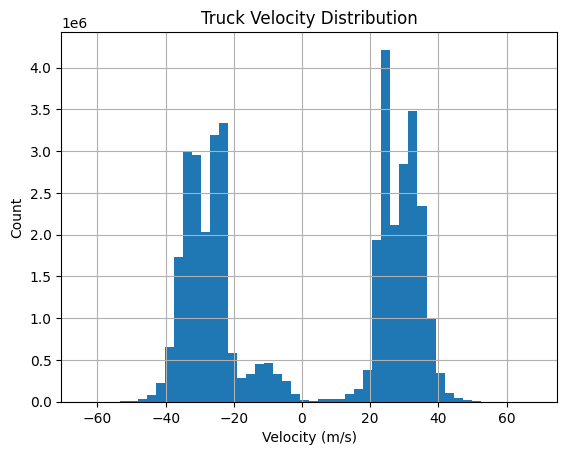

In [4]:
truck_tracks["xVelocity"].hist(bins=50)
plt.title("Truck Velocity Distribution")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Count")
plt.show()

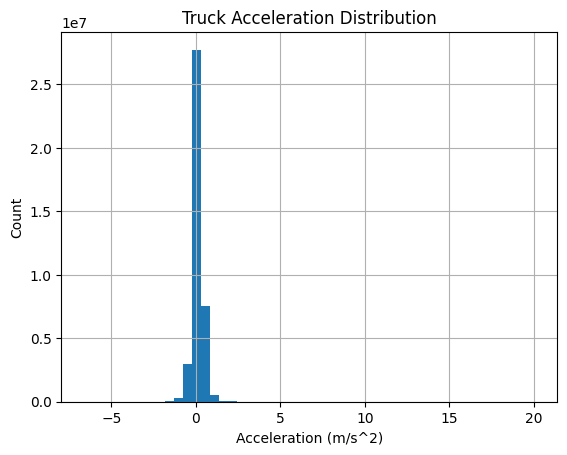

In [5]:
truck_tracks["xAcceleration"].hist(bins=50)
plt.title("Truck Acceleration Distribution")
plt.xlabel("Acceleration (m/s^2)")
plt.ylabel("Count")
plt.show()

In [6]:
sequences = extract_following_sequences(truck_tracks)
print("Number of sequences", len(sequences))

Number of sequences 6003


In [7]:
summary_df = build_sequence_summary_dataframe(sequences)
summary_df.head()

,leader_id,follower_id,duration_frames,convergence_time,initial_spacing,steady_spacing,min_spacing,max_spacing,spacing_std,initial_velocity,...,relative_acceleration_std,mean_thw,std_thw,min_thw,max_thw,velocity_oscillation,accel_oscillation,spacing_oscillation,rms_acceleration,rms_jerk
0,17,8,204,2.24,53.50,60.3744,53.50,60.86,2.057948,27.24,...,NaN,2.034510,0.025907,1.96,2.06,0.857699,0.173230,2.057948,0.376160,0.134447
1,18,9,272,8.44,26.52,38.0236,26.27,39.21,4.221411,33.24,...,NaN,0.949191,0.121628,0.79,1.14,0.332880,0.203108,4.221411,0.223069,0.146967
2,16,11,212,6.60,47.27,57.2108,47.20,59.18,3.647506,30.83,...,NaN,1.633396,0.097562,1.52,1.82,0.347520,0.112562,3.647506,0.215891,0.145693
3,14,11,354,0.80,23.06,20.2028,19.93,23.06,0.570050,23.51,...,NaN,0.911751,0.019752,0.87,0.98,0.226922,0.120427,0.570050,0.129303,0.123222
4,25,11,202,5.24,29.68,18.7940,17.81,29.68,3.436378,31.68,...,NaN,0.741238,0.095234,0.60,0.93,0.683359,0.082015,3.436378,0.268085,0.123130


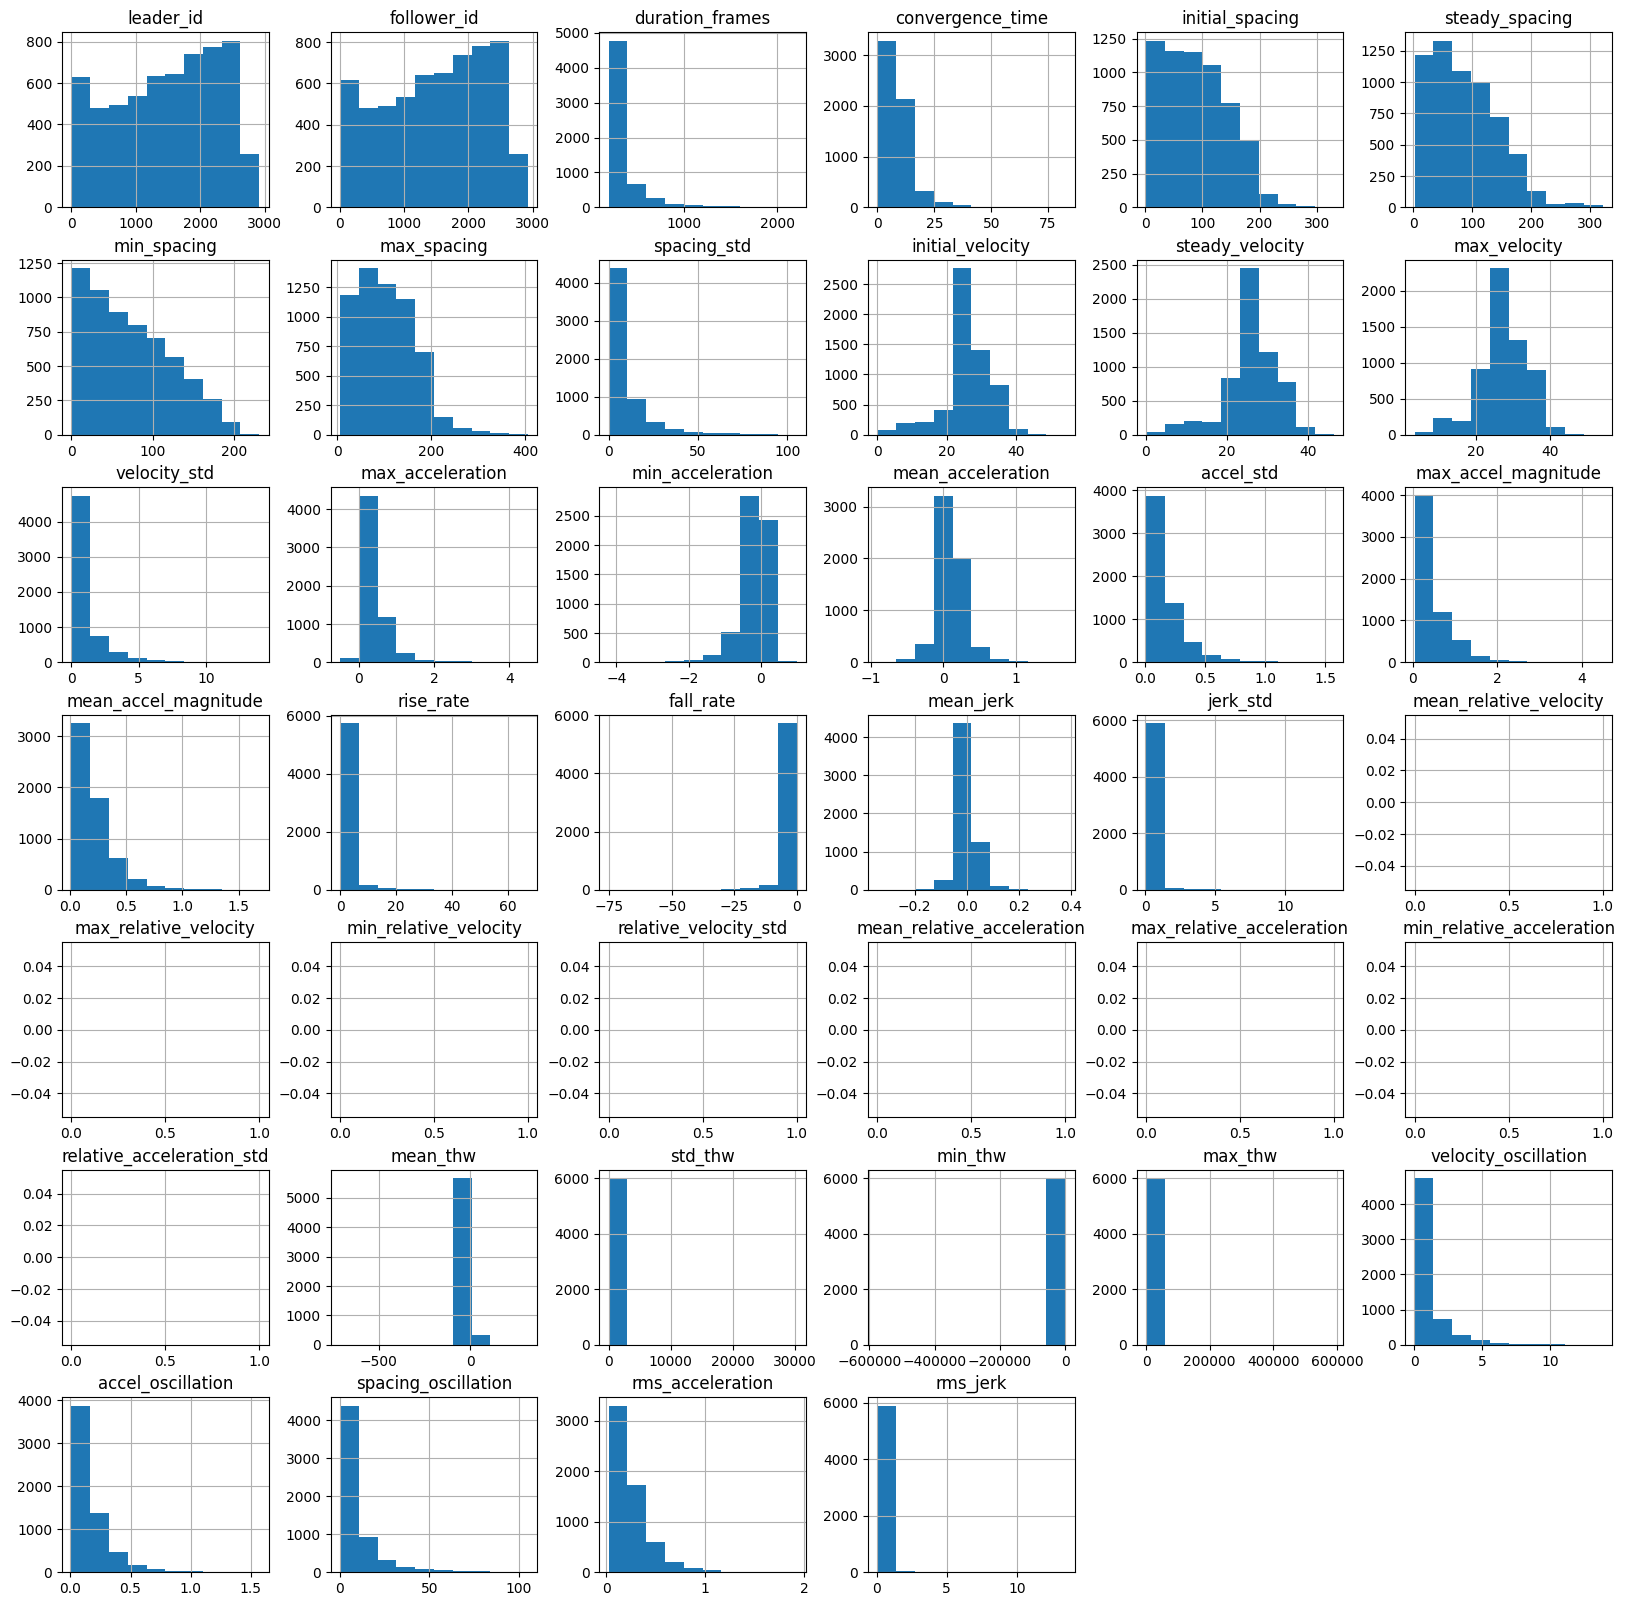

,leader_id,follower_id,duration_frames,convergence_time,initial_spacing,steady_spacing,min_spacing,max_spacing,spacing_std,initial_velocity,...,relative_acceleration_std,mean_thw,std_thw,min_thw,max_thw,velocity_oscillation,accel_oscillation,spacing_oscillation,rms_acceleration,rms_jerk
leader_id,1.000000,0.999942,0.026995,-0.035522,-0.211963,-0.231587,-0.198019,-0.252542,-0.134624,0.103101,...,NaN,-0.023870,-0.002159,0.007480,0.006418,0.020118,0.118551,-0.134624,0.118791,-0.053496
follower_id,0.999942,1.000000,0.026475,-0.035542,-0.206989,-0.227731,-0.193421,-0.248419,-0.134183,0.101585,...,NaN,-0.023879,-0.002379,0.007157,0.005573,0.019114,0.116834,-0.134183,0.117322,-0.054340
duration_frames,0.026995,0.026475,1.000000,0.628204,-0.371290,-0.306358,-0.442164,-0.250442,0.174677,-0.486154,...,NaN,-0.045684,0.074294,-0.073352,0.063969,0.555787,0.373212,0.174677,0.216738,0.171684
convergence_time,-0.035522,-0.035542,0.628204,1.000000,-0.149472,-0.073526,-0.257275,0.017231,0.378878,-0.272550,...,NaN,-0.038634,0.064827,-0.068873,0.049134,0.445190,0.185643,0.378878,0.119490,0.134923
initial_spacing,-0.211963,-0.206989,-0.371290,-0.149472,1.000000,0.768021,0.894178,0.856481,0.175287,0.227693,...,NaN,0.180951,-0.025702,0.030471,-0.013474,-0.207129,-0.357781,0.175287,-0.262720,-0.075409
steady_spacing,-0.231587,-0.227731,-0.306358,-0.073526,0.768021,1.000000,0.863477,0.900529,0.325922,0.089760,...,NaN,0.159163,-0.043210,0.040129,-0.038715,-0.136135,-0.413250,0.325922,-0.364693,-0.029016
min_spacing,-0.198019,-0.193421,-0.442164,-0.257275,0.894178,0.863477,1.000000,0.780172,-0.067097,0.113307,...,NaN,0.170344,-0.047756,0.044725,-0.041853,-0.349413,-0.479794,-0.067097,-0.415082,-0.121206
max_spacing,-0.252542,-0.248419,-0.250442,0.017231,0.856481,0.900529,0.780172,1.000000,0.547689,0.184797,...,NaN,0.169696,-0.024585,0.028335,-0.014313,-0.015292,-0.318340,0.547689,-0.245357,0.028119
spacing_std,-0.134624,-0.134183,0.174677,0.378878,0.175287,0.325922,-0.067097,0.547689,1.000000,0.140502,...,NaN,0.047179,0.019992,-0.010726,0.027948,0.427469,0.112530,1.000000,0.137045,0.208701
initial_velocity,0.103101,0.101585,-0.486154,-0.272550,0.227693,0.089760,0.113307,0.184797,0.140502,1.000000,...,NaN,0.001765,-0.089888,0.090393,-0.066000,-0.110128,-0.121173,0.140502,0.025560,0.061252


In [8]:
summary_df.hist(figsize=(20,20))
plt.show()
summary_df.describe()
summary_df.corr(numeric_only=True)

<Axes: >

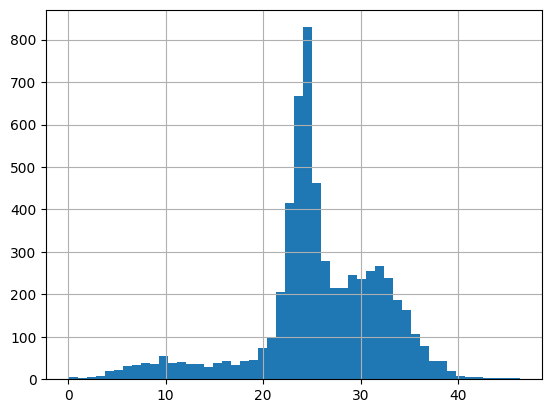

In [9]:
summary_df["steady_velocity"].hist(bins=50)

<Axes: >

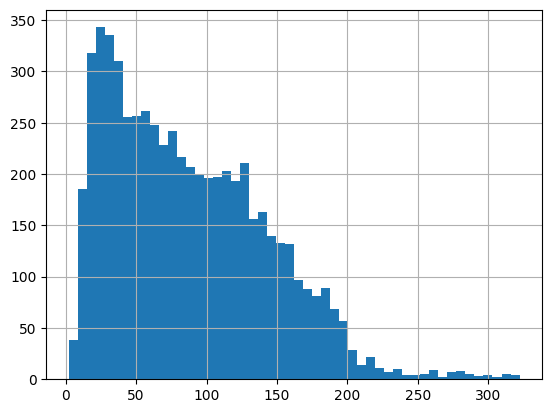

In [10]:
summary_df["steady_spacing"].hist(bins=50)

<Axes: >

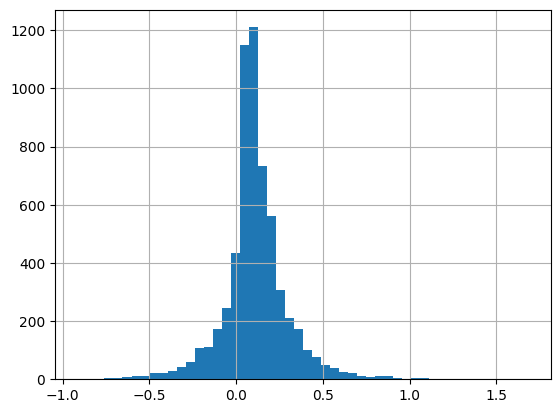

In [11]:
summary_df["mean_acceleration"].hist(bins=50)


<Axes: >

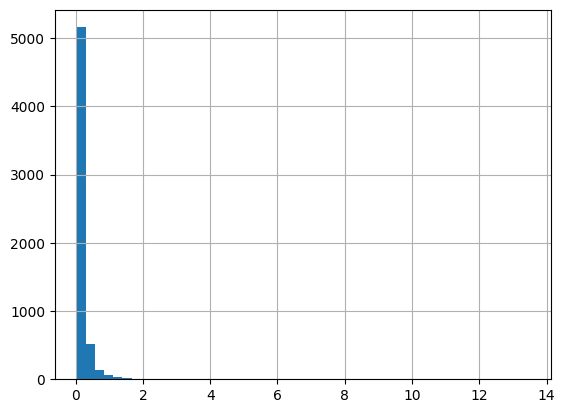

In [12]:
summary_df["rms_jerk"].hist(bins=50)

In [13]:
print(summary_df.dtypes)
print(summary_df["steady_velocity"].head())

leader_id                       int64
follower_id                     int64
duration_frames                 int64
convergence_time              float64
initial_spacing               float64
steady_spacing                float64
min_spacing                   float64
max_spacing                   float64
spacing_std                   float64
initial_velocity              float64
steady_velocity               float64
max_velocity                  float64
velocity_std                  float64
max_acceleration              float64
min_acceleration              float64
mean_acceleration             float64
accel_std                     float64
max_accel_magnitude           float64
mean_accel_magnitude          float64
rise_rate                     float64
fall_rate                     float64
mean_jerk                     float64
jerk_std                      float64
mean_relative_velocity        float64
max_relative_velocity         float64
min_relative_velocity         float64
relative_vel

In [14]:
profiles_df = generate_all_profiles(summary_df)
profiles_df

Quantile thresholds:
  v25: 23.270
  v75: 30.261
  s25: 39.870
  s50: 78.511
  s75: 126.352
  j75: 0.221
  j90: 0.384
  a75: 0.620
  a90: 0.990

Sequences captured: 3893 / 6003 (64.9%)


,profile,num_sequences,cruise_speed,steady_spacing,initial_spacing,rise_rate,fall_rate,convergence_time,velocity_std,spacing_std,accel_std,jerk_std
0,Conservative,469,21.784621,25.0,40.0,0.297441,-0.311834,8.085800,0.423657,6.852440,0.077254,0.107564
1,Normal Highway,1297,25.781995,15.0,25.0,0.320162,-0.318813,7.787047,0.552055,6.504767,0.090124,0.115083
2,Aggressive Merge,1012,23.883483,10.0,20.0,4.309536,-4.935277,12.646339,2.694017,18.221560,0.387791,0.788643
3,Congested,604,13.653659,8.0,15.0,0.949503,-0.911010,11.859404,2.154492,6.774242,0.383629,0.263211
4,Deceleration Event,511,29.612878,12.0,30.0,3.587573,-10.518591,13.993333,2.530426,25.500731,0.233241,1.126839


In [15]:
print(summary_df[["steady_velocity", "steady_spacing"]].describe())
#check overlap between profiles
total = profiles_df["num_sequences"].sum()
print(f"Total sequences across profiles: {total}")
print(f"Total in summary_df: {len(summary_df)}")

       steady_velocity  steady_spacing
count      6003.000000     6003.000000
mean         25.713843       87.513359
std           6.600163       55.770059
min           0.063800        2.138400
25%          23.270000       39.869900
50%          25.142400       78.511400
75%          30.261200      126.352200
max          46.285400      322.083600
Total sequences across profiles: 3893
Total in summary_df: 6003


In [16]:
print(summary_df["steady_velocity"].describe())
print(summary_df["steady_spacing"].describe())
print(summary_df["max_accel_magnitude"].describe())
print(summary_df["rms_jerk"].describe())

count    6003.000000
mean       25.713843
std         6.600163
min         0.063800
25%        23.270000
50%        25.142400
75%        30.261200
max        46.285400
Name: steady_velocity, dtype: float64
count    6003.000000
mean       87.513359
std        55.770059
min         2.138400
25%        39.869900
50%        78.511400
75%       126.352200
max       322.083600
Name: steady_spacing, dtype: float64
count    6003.000000
mean        0.491629
std         0.442288
min         0.050000
25%         0.200000
50%         0.350000
75%         0.620000
max         4.490000
Name: max_accel_magnitude, dtype: float64
count    6003.000000
mean        0.252096
std         0.578661
min         0.050555
25%         0.102942
50%         0.136624
75%         0.220941
max        13.458022
Name: rms_jerk, dtype: float64
